In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Convolution2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.optimizers import SGD
import tensorflow as tf

from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv('creditcard.csv', low_memory=False)
X = df.iloc[:,:-1]
y = df['Class']

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
frauds = df.loc[df['Class'] == 1]
non_frauds = df.loc[df['Class'] == 0]
print("We have", len(frauds), "fraud data points and", len(non_frauds), "regular data points.")

We have 492 fraud data points and 284315 regular data points.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [8]:
print("Size of training set: ", X_train.shape)

Size of training set:  (190820, 30)


# Simplest Neural Network (for testing)

In [9]:
model = Sequential()
model.add(Dense(30, input_dim=30, activation='relu'))     # kernel_initializer='normal'
model.add(Dense(1, activation='sigmoid'))                 # kernel_initializer='normal'
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

C:\Users\likit\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X_train.to_numpy(), y_train, epochs=1)

5964/5964 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9815 - loss: 246.9299


In [13]:
print("Loss: ", model.evaluate(X_test.to_numpy(), y_test, verbose=...))

Loss:  [7.842325210571289, 0.9982125163078308]


In [15]:
y_predicted = model.predict(X_test.to_numpy()).T[0].astype(int)

2938/2938 ━━━━━━━━━━━━━━━━━━━━ 2s 648us/step


Confusion matrix:
[[93819     0]
 [  167     1]]


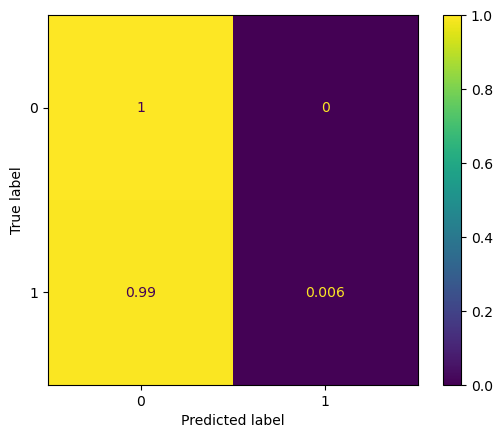

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_right = np.array(y_test)
cm = confusion_matrix(y_right, y_predicted)
print("Confusion matrix:\n%s" % cm)
ConfusionMatrixDisplay.from_predictions(y_right, y_predicted, normalize='true')
plt.show()

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_right, y_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93819
           1       1.00      0.01      0.01       168

    accuracy                           1.00     93987
   macro avg       1.00      0.50      0.51     93987
weighted avg       1.00      1.00      1.00     93987



# Oversampling with gaussian noise (commented out)

In [20]:
# noise = np.random.normal(0,.1,30)

# # 0 is the mean of the normal distribution you are choosing from
# # 1 is the standard deviation of the normal distribution
# # 100 is the number of elements you get in array noise
# noise

In [21]:
# frauds.head()

In [22]:
# for i in range(300):
#     #frauds.iloc[i] += noise[i]
#     frauds.append(frauds.iloc[i % 30] + noise[i % 30])

In [23]:
# NEED TO ADD A (DIFFERENT BUT SIMILAR) RANDOM NOISE ARRAY TO EVERY ROW OF FRAUDS TABLE (WITHOUT CLASS)
# THEN ADD THIS TO ORIGINAL FRAUDS TABLE (MAKING MORE DATA POINTS)
# AND RE SPLIT DATA AND DO NEURAL NET
# ALSO TRY FORCING 50% OF FRAUDS INTO TRAINING SET AND 50% INTO TEST SET

# Neural Network after Oversampling, Scaling, and PCA (10 components)

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from imblearn.over_sampling import SMOTE

sampler = SMOTE()
X2, y2 = sampler.fit_resample(X_train, y_train)

data = scale(X2)
pca = PCA(n_components=10)
X2 = pca.fit_transform(data)
X2

array([[ 2.22810511, -0.1901155 ,  0.86080417, ...,  0.83244374,
         0.15374487, -0.49253084],
       [ 2.64832973, -0.89025678,  0.17271723, ..., -1.05186275,
        -0.79329056, -0.43939639],
       [ 2.36521021,  0.3035714 ,  1.27793081, ...,  1.38534078,
         1.02726988, -0.84605971],
       ...,
       [-4.80955335,  1.91035074, -2.19556979, ...,  0.70727485,
         0.24663105, -0.34811518],
       [-0.73268907, -0.14039581, -1.66193714, ..., -2.30505279,
         0.00695995, -0.3933519 ],
       [-1.24740681,  0.71608009, -1.35176773, ..., -1.83460965,
        -0.59473287,  0.56728981]], shape=(380992, 10))

In [26]:
model2 = Sequential()
model2.add(Dense(10, input_dim=10, activation='relu')) 
model2.add(Dense(27, activation='relu'))
model2.add(Dense(20, activation='relu'))
model2.add(Dense(15, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()

C:\Users\likit\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │           297 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298 (5.07 KB)

 Trainable params: 1,298 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
X2_test = pca.fit_transform(X_test)
h = model2.fit(X2, y2, epochs=5, validation_data=(X2_test, y_test))

Epoch 1/5
11906/11906 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9659 - loss: 0.0944 - val_accuracy: 0.4674 - val_loss: 29730.5215
Epoch 2/5
11906/11906 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9791 - loss: 0.0578 - val_accuracy: 0.4674 - val_loss: 22986.4062
Epoch 3/5
11906/11906 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9835 - loss: 0.0468 - val_accuracy: 0.4674 - val_loss: 26572.4707
Epoch 4/5
11906/11906 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9858 - loss: 0.0408 - val_accuracy: 0.4675 - val_loss: 20427.6973
Epoch 5/5
11906/11906 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9874 - loss: 0.0360 - val_accuracy: 0.4675 - val_loss: 18212.4824


In [28]:
print("Loss: ", model2.evaluate(X2_test, y_test, verbose=2))

2938/2938 - 4s - 1ms/step - accuracy: 0.4675 - loss: 18212.4824
Loss:  [18212.482421875, 0.46747955679893494]


In [29]:
y2_predicted = np.round(model2.predict(X2_test)).T[0]
y2_correct = np.array(y_test)

2938/2938 ━━━━━━━━━━━━━━━━━━━━ 2s 525us/step


Confusion matrix:
[[43826 49993]
 [   57   111]]


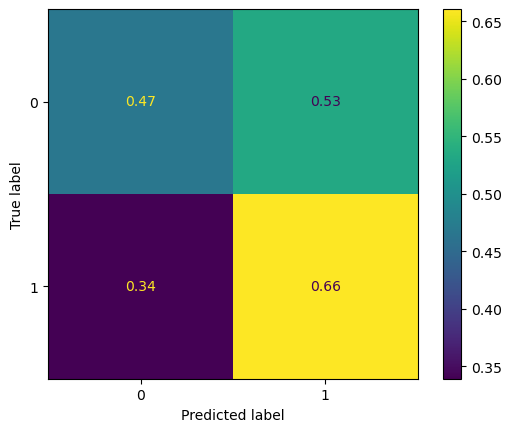

              precision    recall  f1-score   support

           0       1.00      0.47      0.64     93819
           1       0.00      0.66      0.00       168

    accuracy                           0.47     93987
   macro avg       0.50      0.56      0.32     93987
weighted avg       1.00      0.47      0.64     93987



In [31]:
cm2 = confusion_matrix(y2_correct, y2_predicted)
print("Confusion matrix:\n%s" % cm2)
ConfusionMatrixDisplay.from_predictions(y2_correct, y2_predicted, normalize='true')
plt.show()
print(classification_report(y2_correct, y2_predicted))